# Install and Import Library

In [ ]:
# Menginstall Sastrawi, Wordcloud, IndoNLP, dan NLTK
!pip install Sastrawi wordcloud indoNLP

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.9/121.9 kB 5.5 MB/s eta 0:00:00


In [ ]:
# Import Pandas untuk manipulasi dan pengolahan data
import pandas as pd

# Import Regex (re) untuk pembersihan teks
import re

# Import Sastrawi untuk stopword removal
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Import IndoNLP untuk normalisasi teks (kata yang dilebihkan dan slang)
from indoNLP.preprocessing import replace_word_elongation, replace_slang

# Import Wordcloud, Matplotlib, dan Seaborn untuk visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Feature extraction untuk analisis bigram
from sklearn.feature_extraction.text import CountVectorizer

# Import Drive, OS, dan Glob
from google.colab import drive  # menghubungkan Google Drive ke Colab
import glob                     # mencari file berdasarkan pola tertentu
import os                       # mengelola path dan direktori pada sistem file

# Load Data

In [ ]:
# Menghubungkan dengan Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Path utama folder dataset
base_path = '/content/drive/My Drive/skripsi/svm_indobert/data/labeled_data'

# Membuat pola pencarian semua file Excel di seluruh subfolder
joined_files = os.path.join(base_path, '**', '2026_labeled_2_*.xlsx')

# Mengambil semua file Excel secara recursive
file_list = glob.glob(joined_files, recursive=True)

# Memeriksa total file yang ditemukan
print(f'Total file ditemukan: {len(file_list)}\n')

# List untuk menampung DataFrame
df_list = []

# Menampilkan jumlah data per file
print('Jumlah data per file:')
for file in file_list:
    df_temp = pd.read_excel(file)
    df_list.append(df_temp)

    nama_file = os.path.basename(file)
    print(f'{nama_file} -> {len(df_temp)} baris')

Total file ditemukan: 3

Jumlah data per file:
2026_labeled_2_1.xlsx -> 425 baris
2026_labeled_2_2.xlsx -> 70 baris
2026_labeled_2_3.xlsx -> 16 baris


In [ ]:
# Menggabungkan seluruh DataFrame
df = pd.concat(df_list, ignore_index=True)

# Menyimpan hasil gabungan ke CSV
output_path = '/content/drive/My Drive/skripsi/svm_indobert/data/final_data/2026_krl_complaints_labeled_3.csv'
df.to_csv(output_path, index=False)

# Menampilkan ringkasan hasil akhir
print(f'\nTotal data setelah penggabungan: {len(df)}')
print(f'File berhasil disimpan di: {output_path}')


Total data setelah penggabungan: 511
File berhasil disimpan di: /content/drive/My Drive/skripsi/svm_indobert/data/final_data/2026_krl_complaints_labeled_3.csv


In [ ]:
# Preview data
df.head()

,created_at,full_text,label
0,Thu Mar 26 23:43:52 +0000 2026,@CommuterLine pls ini jorok banget?? lagi gaad...,Kebersihan
1,Wed Mar 04 10:57:38 +0000 2026,@CommuterLine min mau konfirmasi ini kok masih...,Pelayanan
2,Fri Feb 27 21:03:04 +0000 2026,@CommuterLine Petugas lu tuh kasih pelajaran j...,Pelayanan
3,Thu Jan 22 11:39:21 +0000 2026,@CommuterLine saya lagi berdiri karena pake ja...,Pelayanan
4,Wed Mar 25 13:26:51 +0000 2026,@CommuterLine min ini di kerta commuter line s...,Pelayanan


# Exploratory Data Analysis

### Helper Function
merupakan fungsi dasar untuk melakukan operasi spesifik dan berulang, serta  menjadi komponen pendukung bagi fungsi lain yang lebih kompleks.

In [ ]:
# Fungsi preprocessing minimal untuk keperluan analisis frekuensi kata (EDA).
def clean_for_freq(text: str, stopwords: set) -> str:
    text = str(text).lower() # lowercase
    text = replace_word_elongation(text)   # normalisasi elongation: 'laamaaa' → 'lama'
    text = replace_slang(text)   # normalisasi slang: 'gak' → 'tidak', 'yg' → 'yang'
    text = re.sub(r'http\S+|@\w+|#\w+|[^a-z\s]', ' ', text)    # hapus noise
    tokens = [w for w in text.split() if w not in stopwords and len(w) > 2]    # hapus stopword
    return ' '.join(tokens)

clean_for_freq(): digunakan untuk membersihkan teks sebelum dilakukan analisis frekuensi. Prosesnya meliputi normalisasi teks seperti lowercasing, penghapusan noise menggunakan regex, penggantian slang, serta filtering stopword dan kata pendek. Output dari fungsi ini adalah teks bersih yang siap digunakan untuk analisis seperti word cloud atau bigram

In [ ]:
# Fungsi untuk mengekstrak top-n bigram beserta frekuensinya dari corpus menggunakan CountVectorizer
def get_top_bigrams(corpus: pd.Series, stopwords: set, n: int = 10) -> list[tuple]:

    # Inisialisasi CountVectorizer untuk ekstraksi bigram (2 kata berurutan)
    vec = CountVectorizer(
        ngram_range=(2, 2),          # hanya mengambil bigram
        stop_words=list(stopwords),  # menghapus stopword dari proses
        min_df=2                     # hanya mempertahankan bigram yang muncul minimal 2 kali
    )

    try:
        # Mengubah corpus teks menjadi matriks fitur (document-term matrix)
        X = vec.fit_transform(corpus)

        # Menjumlahkan frekuensi setiap bigram di seluruh dokumen
        sum_words = X.sum(axis=0)

        # Membuat list pasangan (bigram, frekuensi)
        words_freq = [
            (word, int(sum_words[0, idx]))  # mengambil frekuensi tiap bigram
            for word, idx in vec.vocabulary_.items()  # iterasi seluruh bigram yang terdeteksi
        ]

        # Mengurutkan bigram berdasarkan frekuensi tertinggi, lalu ambil top-n
        return sorted(words_freq, key=lambda x: x[1], reverse=True)[:n]

    except ValueError:
        # Mengembalikan list kosong jika terjadi error (misalnya corpus terlalu sedikit)
        return []

get_top_bigrams(): digunakan untuk mengekstrak pasangan dua kata (bigram) yang paling sering muncul dalam corpus teks menggunakan CountVectorizer. Fungsi ini membantu dalam memahami konteks kata yang sering muncul secara bersamaan dalam setiap kategori.

### Analysis Function
merupakan fungsi yang digunakan untuk menghasilkan informasi kuantitatif dari data dan fitur tambahan yang mendukung pemahaman karakteristik data.

In [ ]:
# Fungsi untuk menghitung frekuensi dan persentase tiap label
def compute_label_stats(df: pd.DataFrame) -> pd.DataFrame:

    # Menghitung jumlah kemunculan tiap label
    counts = df[LABEL_COL].value_counts()

    # Menghitung persentase tiap label terhadap total data
    pct = df[LABEL_COL].value_counts(normalize=True) * 100

    # Menggabungkan frekuensi dan persentase ke dalam satu DataFrame
    summary = pd.DataFrame({
        'Frekuensi': counts,
        'Persentase (%)': pct.round(2)  # membulatkan hingga 2 angka desimal
    })

    # Mengembalikan hasil ringkasan
    return summary

compute_label_stats(): digunakan untuk menghitung frekuensi dan persentase tiap kategori label untuk melihat distribusi data serta mendeteksi potensi class imbalance.

In [ ]:
# Fungsi untuk menambahkan kolom word_length dan char_length
def compute_text_lengths(df: pd.DataFrame) -> pd.DataFrame:

    # Membuat salinan DataFrame agar tidak mengubah data asli (avoid side effect)
    df = df.copy()

    # Menghitung jumlah kata per teks (berdasarkan spasi)
    df['word_length'] = df[TEXT_COL].astype(str).apply(lambda x: len(x.split()))

    # Menghitung jumlah karakter per teks
    df['char_length'] = df[TEXT_COL].astype(str).apply(len)

    # Mengembalikan DataFrame yang sudah ditambahkan fitur panjang teks
    return df

compute_text_lengths(): digunakan untuk menambahkan fitur baru berupa panjang teks dalam jumlah kata dan karakter, yang digunakan untuk memahami karakteristik teks serta sebagai dasar analisis lanjutan.

In [ ]:
# Fungsi Statistik deskriptif panjang teks per kategori label
def compute_length_per_label(df: pd.DataFrame) -> pd.DataFrame:

    # Mengelompokkan data berdasarkan label
    # lalu menghitung statistik (mean, median, max, min) untuk panjang kata & karakter
    return df.groupby(LABEL_COL)[['word_length', 'char_length']].agg(
        ['mean', 'median', 'max', 'min']

    # Membulatkan hasil hingga 2 angka desimal agar lebih rapi
    ).round(2)

compute_length_per_label(): digunakan untuk menghitung statistik deskriptif panjang teks per kategori label, seperti rata-rata, median, maksimum, dan minimum, untuk melihat perbedaan karakteristik antar kategori.

In [ ]:
# Fungsi untuk rekomendasi max_length IndoBERT berdasarkan persentil panjang kata
def recommend_max_length(df: pd.DataFrame, percentile: float = 0.95) -> int:

    # Mengambil nilai persentil dari distribusi panjang kata
    # Contoh: percentile=0.95 → mencakup 95% data
    p_val = int(df['word_length'].quantile(percentile))

    # Mengonversi jumlah kata ke estimasi token (≈ satu kata itu kurang lebih jadi dua token)
    # serta membatasi maksimum 128 token untuk efisiensi
    recommended = min(128, p_val * 2)

    # Menampilkan informasi persentil panjang teks
    print(f'[INFO] Persentil ke-{int(percentile*100)} jumlah kata : {p_val}')

    # Menampilkan rekomendasi max_length untuk IndoBERT
    print(f'[INFO] Rekomendasi max_length IndoBERT              : {recommended} token')

    # Mengembalikan nilai max_length yang direkomendasikan
    return recommended

recommend_max_length(): digunakan untuk menentukan nilai maksimum panjang input (max_length) untuk IndoBERT berdasarkan distribusi panjang teks menggunakan pendekatan persentil, sehingga tidak ditentukan secara arbitrer.

### Visualization Function
mengacu pada fungsi yang digunakan untuk menyajikan hasil analisis dalam bentuk grafik.

In [ ]:
# Visualisasi distribusi label dengan anotasi frekuensi & persentase
def plot_label_distribution(label_stats: pd.DataFrame) -> None:

    fig, ax = plt.subplots(figsize=(8, 5))  # Membuat canvas plot

    # Membuat bar chart dari frekuensi tiap label
    bars = ax.bar(
        label_stats.index,
        label_stats['Frekuensi'],
        color=COLORS[:len(label_stats)],
        edgecolor='white', linewidth=0.8
    )

    # Menambahkan anotasi jumlah dan persentase di atas setiap bar
    for bar, pct in zip(bars, label_stats['Persentase (%)']):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{int(bar.get_height())}\n({pct:.1f}%)",
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

    ax.set_title('Distribusi Label Kategori Keluhan\nKAI Commuter Line',
                 fontsize=13, fontweight='bold', pad=15)  # Judul grafik
    ax.set_xlabel('Kategori Keluhan')  # Label sumbu X
    ax.set_ylabel('Jumlah Tweet')      # Label sumbu Y

    ax.set_xticks(range(len(label_stats.index)))  # Sinkronisasi posisi tick
    ax.set_xticklabels(label_stats.index, rotation=30, ha='right')  # Label kategori

    ax.spines[['top', 'right']].set_visible(False)  # Hilangkan border atas & kanan

    plt.tight_layout()
    plt.show()

plot_label_distribution(): digunakan untuk menampilkan distribusi jumlah data per kategori dalam bentuk bar chart, lengkap dengan anotasi frekuensi dan persentase.

In [ ]:
# Visualisasi distribusi panjang kata & karakter per kategori
def plot_text_length_boxplot(df: pd.DataFrame) -> None:

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))  # Dua subplot berdampingan

    # Boxplot jumlah kata per kategori
    sns.boxplot(data=df, x=LABEL_COL, y='word_length',
                palette=COLORS[:df[LABEL_COL].nunique()], ax=axes[0])
    axes[0].set_title('Jumlah Kata per Kategori', fontweight='bold')
    axes[0].tick_params(axis='x', rotation=30)

    # Boxplot jumlah karakter per kategori
    sns.boxplot(data=df, x=LABEL_COL, y='char_length',
                palette=COLORS[:df[LABEL_COL].nunique()], ax=axes[1])
    axes[1].set_title('Jumlah Karakter per Kategori', fontweight='bold')
    axes[1].tick_params(axis='x', rotation=30)

    # Menghapus border atas & kanan untuk kedua plot
    for ax in axes:
        ax.spines[['top', 'right']].set_visible(False)

    plt.suptitle('Analisis Panjang Teks per Kategori',
                 fontsize=13, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.show()

plot_text_length_boxplot(): digunakan untuk menampilkan distribusi panjang teks per kategori dalam bentuk boxplot untuk melihat sebaran, median, dan potensi outlier.

In [ ]:
# Visualisasi wordcloud untuk setiap kategori label
def plot_wordcloud_per_label(df: pd.DataFrame) -> None:

    categories = df[LABEL_COL].dropna().unique()  # Ambil label unik
    n_cols = 2
    n_rows = (len(categories) + 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes = axes.flatten()

    for idx, label in enumerate(categories):

        # Menggabungkan seluruh teks dalam satu kategori
        combined = ' '.join(df[df[LABEL_COL] == label][TEXT_CLEAN].dropna())

        if not combined.strip():  # Skip jika teks kosong
            axes[idx].set_visible(False)
            continue

        # Membuat wordcloud
        wc = WordCloud(
            width=800, height=400,
            background_color='white',
            colormap='tab10',
            max_words=100,
            stopwords=STOPWORDS_ID,
            collocations=False
        ).generate(combined)

        axes[idx].imshow(wc, interpolation='bilinear')  # Tampilkan wordcloud
        axes[idx].axis('off')
        axes[idx].set_title(f'Kategori: {label}', fontweight='bold')

    # Menyembunyikan subplot kosong
    for j in range(len(categories), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Word Cloud per Kategori Keluhan\n(setelah preprocessing)',
                 fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

plot_wordcloud_per_label(): digunakan untuk menampilkan kata-kata yang paling dominan dalam setiap kategori menggunakan word cloud sebagai bentuk validasi awal terhadap hasil pelabelan.

In [ ]:
# Visualisasi top-N bigram per kategori dalam bentuk horizontal bar chart
def plot_bigram_per_label(df: pd.DataFrame, n: int = 10) -> None:

    categories = df[LABEL_COL].dropna().unique()  # Ambil label unik
    n_cols = 2
    n_rows = (len(categories) + 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes = axes.flatten()

    for idx, label in enumerate(categories):

        # Ambil corpus teks per kategori
        corpus = df[df[LABEL_COL] == label][TEXT_CLEAN].dropna()

        # Ambil bigram teratas
        bigrams = get_top_bigrams(corpus, STOPWORDS_ID, n=n)

        if not bigrams:  # Skip jika tidak ada bigram valid
            axes[idx].set_visible(False)
            continue

        words, freqs = zip(*bigrams)

        # Plot horizontal bar chart (dibalik agar terbesar di atas)
        axes[idx].barh(words[::-1], freqs[::-1],
                       color=COLORS[idx % len(COLORS)], alpha=0.8)

        axes[idx].set_title(f'Top Bigram — {label}', fontweight='bold')
        axes[idx].set_xlabel('Frekuensi')

        axes[idx].spines[['top', 'right']].set_visible(False)

    # Menyembunyikan subplot kosong
    for j in range(len(categories), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Analisis Bigram per Kategori Keluhan',
                 fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

plot_bigram_per_label(): digunakan untuk menampilkan pasangan kata yang paling sering muncul dalam setiap kategori dalam bentuk horizontal bar chart untuk memahami konteks keluhan.

### Runner

In [ ]:
# Konfigurasi dan Konstanta
LABEL_COL   = 'label'
TEXT_COL    = 'full_text'
TEXT_CLEAN  = 'text_clean_freq'   # kolom teks bersih khusus EDA
COLORS      = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

# Stopwords
factory_sw  = StopWordRemoverFactory()
STOPWORDS_ID = set(factory_sw.get_stop_words())

In [ ]:
# Fungsi untuk menjalankan seluruh pipiline EDA
def run_eda(df: pd.DataFrame) -> pd.DataFrame:

    print("=" * 55)
    print("  EXPLORATORY DATA ANALYSIS — KAI COMMUTER COMPLAINT (2026)")
    print("=" * 55)

    # Persiapan kolom bantu
    df[TEXT_CLEAN] = df[TEXT_COL].apply(lambda x: clean_for_freq(x, STOPWORDS_ID))
    df = compute_text_lengths(df)

    # 1. Struktur Data
    print("\n[1/5] Informasi Dataset")
    display(df.info())

    # 2. Distribusi label
    print("\n[2/5] Statistik Deskriptif & Distribusi Label")
    label_stats = compute_label_stats(df)
    print(label_stats)
    plot_label_distribution(label_stats)

    # 3. Panjang teks
    print("\n[3/5] Analisis Panjang Teks")
    print(compute_length_per_label(df))
    plot_text_length_boxplot(df)
    recommend_max_length(df)

    # 4. Word cloud
    print("\n[4/5] Word Cloud per Kategori")
    plot_wordcloud_per_label(df)

    # 5. Bigram
    print("\n[5/5] Analisis Bigram per Kategori")
    plot_bigram_per_label(df)

    print("\nEDA selesai.")
    return df



  EXPLORATORY DATA ANALYSIS — KAI COMMUTER COMPLAINT (2026)

[1/5] Informasi Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 511 entries, 0 to 510
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   created_at       511 non-null    object
 1   full_text        511 non-null    object
 2   label            511 non-null    object
 3   text_clean_freq  511 non-null    object
 4   word_length      511 non-null    int64 
 5   char_length      511 non-null    int64 
dtypes: int64(2), object(4)
memory usage: 24.1+ KB


None


[2/5] Statistik Deskriptif & Distribusi Label
               Frekuensi  Persentase (%)
label                                   
Keterlambatan        205           40.12
Kepadatan            127           24.85
Pelayanan            127           24.85
Keamanan              33            6.46
Kebersihan            19            3.72


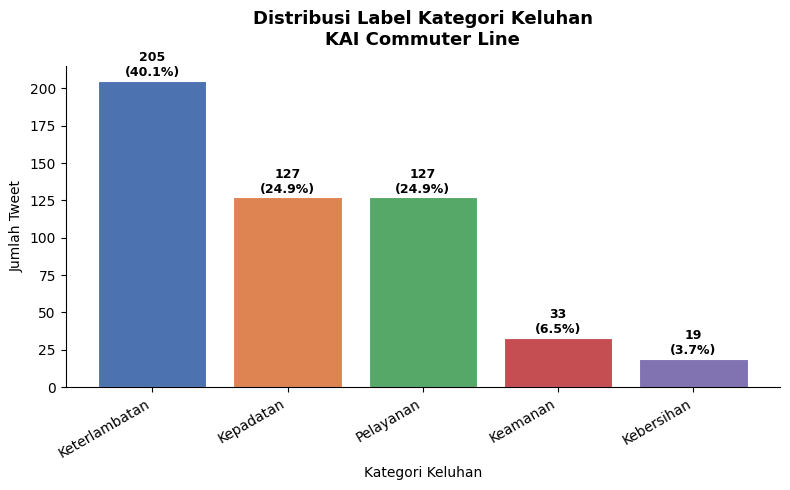


[3/5] Analisis Panjang Teks
              word_length                char_length                
                     mean median max min        mean median  max min
label                                                               
Keamanan            30.64   30.0  46   7      202.91  215.0  299  57
Kebersihan          27.63   31.0  45   8      178.89  182.0  303  49
Kepadatan           25.32   23.0  46   3      164.28  151.0  301  25
Keterlambatan       23.92   21.0  53   2      150.43  140.0  311  19
Pelayanan           30.17   29.0  51  10      193.40  194.0  295  72


/tmp/ipykernel_10553/2427419016.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=LABEL_COL, y='word_length',
/tmp/ipykernel_10553/2427419016.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=LABEL_COL, y='char_length',


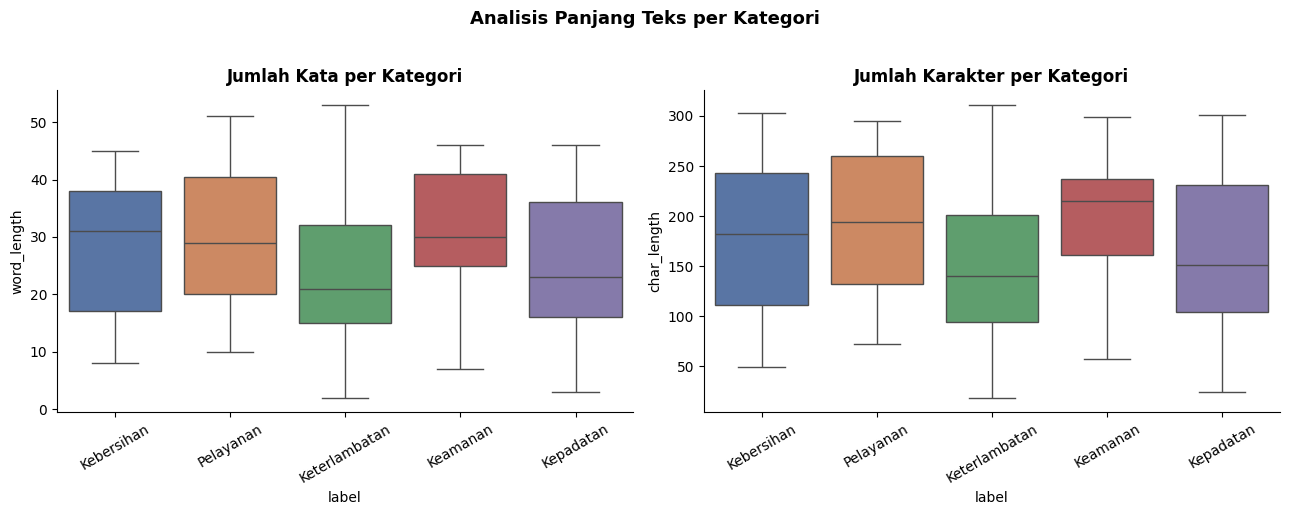

[INFO] Persentil ke-95 jumlah kata : 45
[INFO] Rekomendasi max_length IndoBERT              : 90 token

[4/5] Word Cloud per Kategori


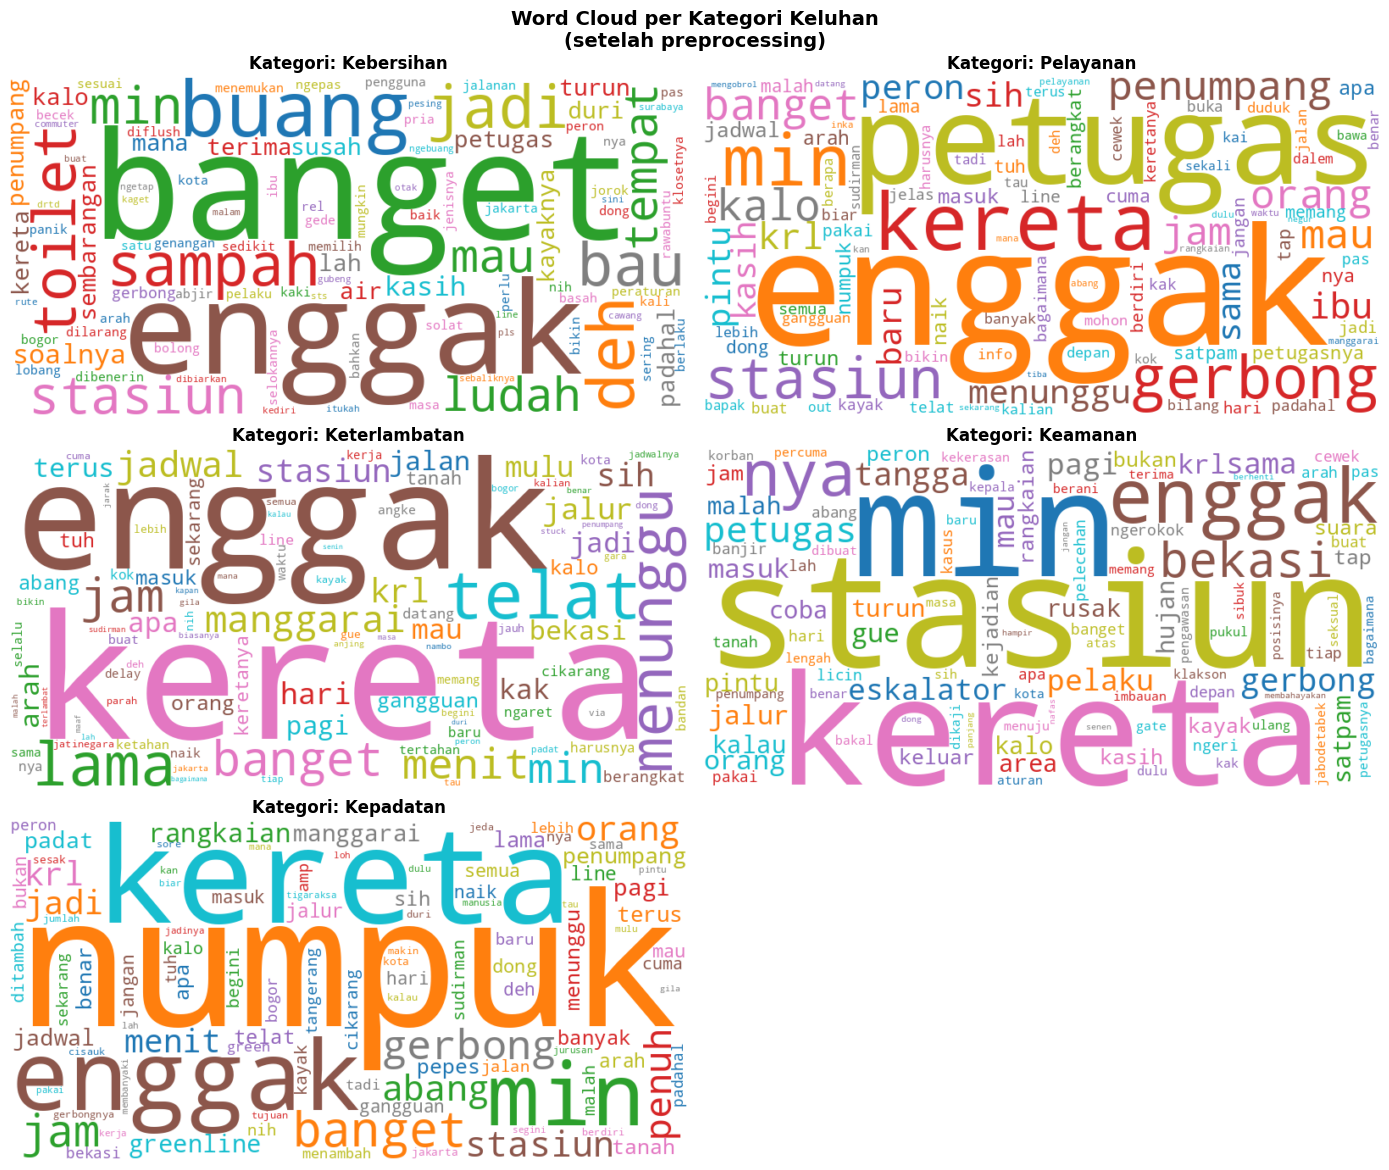


[5/5] Analisis Bigram per Kategori


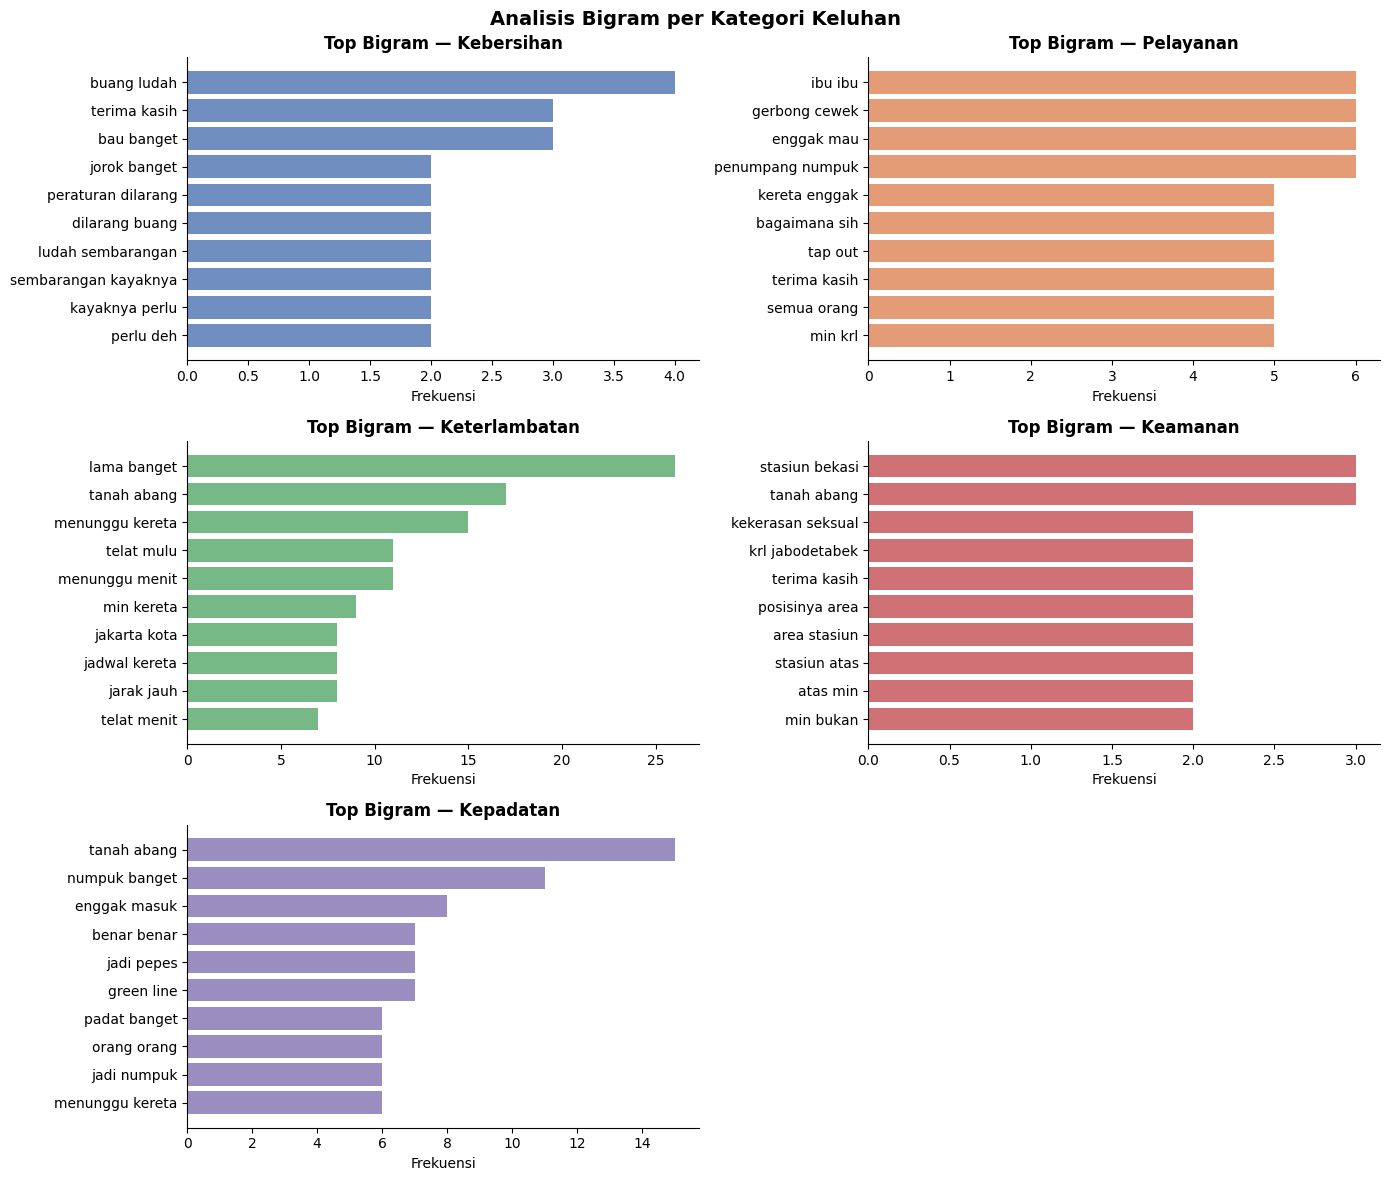


EDA selesai.


In [ ]:
df = run_eda(df)